# Lab 1: Value-Based Deep Reinforcement Learning

## TDDE78 — Deep Reinforcement Learning
### Linköping University, Spring 2026

---

In this lab you will implement **Deep Q-Networks (DQN)** and two key variants:
- **Double DQN** — reduces overestimation bias
- **Dueling DQN** — separates state value from action advantage

The lab is divided into:
- **Part A** — Implementation (fill in the TODO sections)
- **Part B** — Experiments (run systematic evaluations and analyze results)

**Instructions:** Complete all cells marked with `# TODO`. Do not modify the provided helper code unless explicitly asked.

## Setup

Run the cell below to import all necessary libraries and verify your environment.

In [1]:
import os
import numpy as np
import random
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
import gymnasium as gym
import matplotlib.pyplot as plt
from collections import deque
from IPython.display import Video, display
import warnings
warnings.filterwarnings('ignore')

# Import lab utilities
from replay_buffer import ReplayBuffer
from networks import DQNNetwork, DuelingDQNNetwork

# Check device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# Resolve experiments directory relative to this notebook's location
_here = globals().get('__vsc_ipynb_file__', os.path.abspath(''))
_nb_dir = os.path.dirname(_here) if os.path.isfile(_here) else _here
EXPERIMENTS_DIR = os.path.normpath(os.path.join(_nb_dir, '..', 'experiments'))
print(f"Experiments directory: {EXPERIMENTS_DIR}")

# For reproducibility
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)

set_seed(42)
print("Setup complete!")

Using device: cpu
Experiments directory: c:\Users\arvid\Code\tdde78\labs\lab1_value_based\experiments
Setup complete!


---

# Part A — Implementation

---

## A.1 — Explore the Environment

Before implementing DQN, let's understand the environment we'll be working with.

**CartPole-v1:** A pole is attached to a cart moving along a frictionless track. The goal is to keep the pole balanced by applying forces to the left or right.

In [2]:
# Explore the CartPole environment
env = gym.make('CartPole-v1')

print(f"Observation space: {env.observation_space}")
print(f"  Shape: {env.observation_space.shape}")
print(f"  Low:  {env.observation_space.low}")
print(f"  High: {env.observation_space.high}")
print()
print(f"Action space: {env.action_space}")
print(f"  Number of actions: {env.action_space.n}")
print(f"  Actions: 0 = push left, 1 = push right")

# Run a random episode
obs, info = env.reset(seed=42)
total_reward = 0
for step in range(200):
    action = env.action_space.sample()  # Random action
    obs, reward, terminated, truncated, info = env.step(action)
    total_reward += reward
    if terminated or truncated:
        break

print(f"\nRandom agent — Episode length: {step+1}, Total reward: {total_reward}")
env.close()

Observation space: Box([-4.8               -inf -0.41887903        -inf], [4.8               inf 0.41887903        inf], (4,), float32)
  Shape: (4,)
  Low:  [-4.8               -inf -0.41887903        -inf]
  High: [4.8               inf 0.41887903        inf]

Action space: Discrete(2)
  Number of actions: 2
  Actions: 0 = push left, 1 = push right

Random agent — Episode length: 16, Total reward: 16.0


## A.2 — Replay Buffer

Open `replay_buffer.py` and implement the `push()` and `sample()` methods.

**Why experience replay?**
- Consecutive transitions are highly correlated (the agent visits similar states in sequence)
- Training on correlated data leads to unstable learning
- Random sampling from a buffer breaks these correlations
- Transitions can be reused multiple times, improving sample efficiency

After implementing, run the test cell below to verify.

In [3]:
# Test your ReplayBuffer implementation
from replay_buffer import ReplayBuffer

# Create a small buffer
test_buffer = ReplayBuffer(capacity=100, seed=42)

# Add some fake transitions
for i in range(50):
    state = np.array([i, i+1, i+2, i+3], dtype=np.float32)
    action = i % 2
    reward = float(i)
    next_state = np.array([i+1, i+2, i+3, i+4], dtype=np.float32)
    done = (i == 49)
    test_buffer.push(state, action, reward, next_state, done)

assert len(test_buffer) == 50, f"Expected 50 transitions, got {len(test_buffer)}"

# Sample a batch
states, actions, rewards, next_states, dones = test_buffer.sample(batch_size=16)

assert states.shape == (16, 4), f"States shape should be (16, 4), got {states.shape}"
assert actions.shape == (16,), f"Actions shape should be (16,), got {actions.shape}"
assert rewards.shape == (16,), f"Rewards shape should be (16,), got {rewards.shape}"
assert next_states.shape == (16, 4), f"Next states shape should be (16, 4), got {next_states.shape}"
assert dones.shape == (16,), f"Dones shape should be (16,), got {dones.shape}"
assert states.dtype == np.float32, f"States dtype should be float32, got {states.dtype}"
assert actions.dtype == np.int64, f"Actions dtype should be int64, got {actions.dtype}"

print("All ReplayBuffer tests passed!")
print(f"Sample states shape: {states.shape}")
print(f"Sample actions: {actions[:5]}")

All ReplayBuffer tests passed!
Sample states shape: (16, 4)
Sample actions: [0 1 1 1 1]


## A.3 — DQN Network

Open `networks.py` and implement the `DQNNetwork` class.

The network is a simple MLP:
```
State (4) → Linear(128) → ReLU → Linear(128) → ReLU → Linear(action_dim)
```

The output is a vector of Q-values, one for each action.

In [4]:
# Test your DQNNetwork implementation
from networks import DQNNetwork

test_net = DQNNetwork(state_dim=4, action_dim=2).to(device)

# Test forward pass
test_state = torch.randn(8, 4).to(device)  # batch of 8 states
q_values = test_net(test_state)

assert q_values.shape == (8, 2), f"Output shape should be (8, 2), got {q_values.shape}"

# Count parameters
n_params = sum(p.numel() for p in test_net.parameters())
print(f"DQNNetwork — output shape: {q_values.shape}, parameters: {n_params:,}")
print(f"Q-values for first state: {q_values[0].detach().cpu().numpy()}")
print("DQNNetwork test passed!")

DQNNetwork — output shape: torch.Size([8, 2]), parameters: 10,934
Q-values for first state: [-0.02283453 -0.07539523]
DQNNetwork test passed!


## A.4 — Dueling DQN Network

Now implement the `DuelingDQNNetwork` in `networks.py`.

```
State (4) → Linear(128) → ReLU → [shared features]
                                    ├── Linear(128) → ReLU → Linear(1)           → V(s)
                                    └── Linear(128) → ReLU → Linear(action_dim)  → A(s,a)

Q(s,a) = V(s) + A(s,a) - mean(A(s,:))
```

In [5]:
# Test your DuelingDQNNetwork implementation
from networks import DuelingDQNNetwork

test_dueling = DuelingDQNNetwork(state_dim=4, action_dim=2).to(device)

# Test forward pass
test_state = torch.randn(8, 4).to(device)
q_values = test_dueling(test_state)

assert q_values.shape == (8, 2), f"Output shape should be (8, 2), got {q_values.shape}"

n_params = sum(p.numel() for p in test_dueling.parameters())
print(f"DuelingDQNNetwork — output shape: {q_values.shape}, parameters: {n_params:,}")
print(f"Q-values for first state: {q_values[0].detach().cpu().numpy()}")
print("DuelingDQNNetwork test passed!")

DuelingDQNNetwork — output shape: torch.Size([8, 2]), parameters: 34,051
Q-values for first state: [-0.22718501  0.10075587]
DuelingDQNNetwork test passed!


## A.5 — DQN Agent

Now implement the complete DQN agent. This is the core of the lab.

The agent needs to:
1. **Select actions** using epsilon-greedy exploration
2. **Store transitions** in the replay buffer
3. **Train** by sampling mini-batches and computing the TD loss
4. **Update the target network** periodically

Fill in all the TODO sections in the cell below.

In [6]:
class DQNAgent:
    """
    DQN Agent with support for Double DQN.

    Args:
        state_dim (int): Dimension of state space.
        action_dim (int): Number of actions.
        lr (float): Learning rate.
        gamma (float): Discount factor.
        epsilon_start (float): Initial exploration rate.
        epsilon_end (float): Final exploration rate.
        epsilon_decay (int): Number of steps over which epsilon decays linearly.
        buffer_size (int): Replay buffer capacity.
        batch_size (int): Mini-batch size for training.
        target_network_frequency (int): Steps between target network hard updates.
        max_grad_norm (float): Gradient clipping threshold.
        use_double_dqn (bool): Whether to use Double DQN target computation.
        use_dueling (bool): Whether to use Dueling DQN architecture.
        seed (int): Random seed.
    """

    def __init__(
        self,
        state_dim: int,
        action_dim: int,
        lr: float = 2.5e-4,
        gamma: float = 0.99,
        epsilon_start: float = 1.0,
        epsilon_end: float = 0.05,
        epsilon_decay: int = 50000,
        buffer_size: int = 10000,
        batch_size: int = 128,
        target_network_frequency: int = 500,
        max_grad_norm: float = 10.0,
        use_double_dqn: bool = False,
        use_dueling: bool = False,
        seed: int = 42,
    ):
        self.action_dim = action_dim
        self.gamma = gamma
        self.epsilon_start = epsilon_start
        self.epsilon_end = epsilon_end
        self.epsilon_decay = epsilon_decay
        self.batch_size = batch_size
        self.target_network_frequency = target_network_frequency
        self.max_grad_norm = max_grad_norm
        self.use_double_dqn = use_double_dqn
        self.steps_done = 0

        # =====================================================================
        # TODO: Initialize the following:
        #
        # 1. self.replay_buffer — a ReplayBuffer with the given capacity and seed
        # 2. self.q_network — the online Q-network (DQN or Dueling, based on use_dueling)
        # 3. self.target_network — a copy of the Q-network (same architecture)
        # 4. Copy the weights from q_network to target_network
        #    Hint: self.target_network.load_state_dict(self.q_network.state_dict())
        # 5. Set target_network to eval mode: self.target_network.eval()
        # 6. self.optimizer — Adam optimizer for q_network with learning rate lr
        # =====================================================================
        self.replay_buffer = ReplayBuffer(buffer_size, seed)

        #Init target_network as copy of q-network, load dueling if desired else regular DQN
        if use_dueling:
            self.q_network = DuelingDQNNetwork(state_dim, action_dim).to(device) #Using our selected device, like cells above
            self.target_network = DuelingDQNNetwork(state_dim, action_dim).to(device)
        else:
            self.q_network = DQNNetwork(state_dim, action_dim).to(device)
            self.target_network = DQNNetwork(state_dim, action_dim).to(device)

        #Copy weight from q_net to target_net and set target_net to eval mode
        self.target_network.load_state_dict(self.q_network.state_dict())
        self.target_network.eval()

        #torch.optim.Adam requires params as input, .parameters() to get q_network params
        self.optimizer = torch.optim.Adam(self.q_network.parameters(), lr=lr)

    def get_epsilon(self):
        """Compute current epsilon using linear decay."""
        # =====================================================================
        # TODO: Implement linear epsilon decay.
        #
        # Epsilon should linearly decrease from epsilon_start to epsilon_end
        # over epsilon_decay steps, then stay at epsilon_end.
        #
        # Formula: eps = max(epsilon_end, epsilon_start - steps_done * (epsilon_start - epsilon_end) / epsilon_decay)
        # =====================================================================
        eps = self.epsilon_start - self.steps_done * (self.epsilon_start - self.epsilon_end) / self.epsilon_decay
        return max(self.epsilon_end, eps)

    def select_action(self, state):
        """
        Select an action using epsilon-greedy policy.

        Args:
            state: numpy array of shape (state_dim,)

        Returns:
            int: selected action
        """
        # =====================================================================
        # TODO: Implement epsilon-greedy action selection.
        #
        # 1. Increment self.steps_done
        # 2. Get current epsilon via self.get_epsilon()
        # 3. With probability epsilon, return a random action
        # 4. Otherwise, convert state to tensor, pass through q_network,
        #    and return the action with the highest Q-value
        #
        # Remember to:
        #   - Use torch.no_grad() when computing Q-values for action selection
        #   - Move tensor to the correct device
        # =====================================================================
        self.steps_done += 1

        epsilon = self.get_epsilon()

        #Random action
        if np.random.rand() < epsilon:
            #returns random int between 0 and action_dim, AKA index for random action
            return np.random.randint(self.action_dim)
        
        #.unsqueeze() needed because network expects (batch_size, state_dim)
        state = torch.FloatTensor(state).unsqueeze(0).to(device)

        #Greedy action
        with torch.no_grad():
            q_values = self.q_network(state)
            action = q_values.argmax(dim=1).item() #torch.Tensor.item converts to standard Python number
        return action
        
    def compute_loss(self, batch):
        """
        Compute the DQN loss (or Double DQN loss).

        Args:
            batch: tuple of (states, actions, rewards, next_states, dones) as numpy arrays

        Returns:
            torch.Tensor: scalar loss value
        """
        states, actions, rewards, next_states, dones = batch

        # Convert to tensors
        states = torch.FloatTensor(states).to(device)
        actions = torch.LongTensor(actions).to(device)
        rewards = torch.FloatTensor(rewards).to(device)
        next_states = torch.FloatTensor(next_states).to(device)
        dones = torch.FloatTensor(dones).to(device)

        # =====================================================================
        # TODO: Compute the DQN loss.
        #
        # Step 1: Compute current Q-values
        #   - Pass states through self.q_network
        #   - Select the Q-values corresponding to the taken actions
        #   - Hint: Use .gather(1, actions.unsqueeze(1)).squeeze(1)
        #
        # Step 2: Compute target Q-values (no gradient!)
        #   with torch.no_grad():
        #
        #   If self.use_double_dqn is True (Double DQN):
        #     - Use q_network to SELECT the best action for next_states:
        #       best_actions = q_network(next_states).argmax(dim=1)
        #     - Use target_network to EVALUATE those actions:
        #       next_q = target_network(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
        #
        #   If self.use_double_dqn is False (Standard DQN):
        #     - Use target_network to both select and evaluate:
        #       next_q = target_network(next_states).max(dim=1)[0]
        #
        #   Target: y = rewards + gamma * next_q * (1 - dones)
        #
        # Step 3: Compute MSE loss between current Q-values and targets
        #   loss = F.mse_loss(current_q, target_q)
        # =====================================================================
        #Current Q-values
        q_values = self.q_network(states)
        current_q = q_values.gather(1, actions.unsqueeze(1)).squeeze(1)

        #Target Q-values
        with torch.no_grad():
            if self.use_double_dqn:
                best_actions = self.q_network(next_states).argmax(dim=1)
                
                next_q = self.target_network(next_states).gather(1, best_actions.unsqueeze(1)).squeeze(1)
            else:
                #Standard DQN
                next_q = self.target_network(next_states).max(dim=1)[0]

            target = rewards + self.gamma * next_q * (1 - dones)

        #Calculate loss
        loss = F.mse_loss(current_q, target)
        return loss

    def train_step(self, global_step: int):
        """
        Perform one training step: sample batch, compute loss, update weights.

        Args:
            global_step (int): Current total environment step count.
                               Used to decide when to update the target network.

        Returns:
            float: loss value (or None if buffer doesn't have enough samples)
        """
        # =====================================================================
        # TODO: Implement one training step.
        #
        # 1. Check if replay buffer has enough samples (>= batch_size)
        #    If not, return None
        # 2. Sample a batch from the replay buffer
        # 3. Compute the loss using self.compute_loss()
        # 4. Backpropagate:
        #    optimizer.zero_grad()
        #    loss.backward()
        #    torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), self.max_grad_norm)
        #    optimizer.step()
        # 5. Hard target network update every target_network_frequency steps:
        #    if global_step % self.target_network_frequency == 0:
        #        self.target_network.load_state_dict(self.q_network.state_dict())
        # 6. Return the loss value as a float: loss.item()
        # =====================================================================
        if len(self.replay_buffer) < self.batch_size:
            return None
        
        batch = self.replay_buffer.sample(self.batch_size)
        loss = self.compute_loss(batch)

        #Backpropagation
        self.optimizer.zero_grad()
        loss.backward()
        torch.nn.utils.clip_grad_norm_(self.q_network.parameters(), self.max_grad_norm)
        self.optimizer.step()

        #Target network update
        if global_step % self.target_network_frequency == 0:
            self.target_network.load_state_dict(self.q_network.state_dict())

        return loss.item()

print("DQNAgent class defined!")

DQNAgent class defined!


## A.6 — Training Loop

Now let's put everything together and train the DQN agent.

In [7]:
def train_dqn(
    env_name: str = "CartPole-v1",
    num_episodes: int = 500,
    learning_starts: int = 1000,
    train_frequency: int = 10,
    use_double_dqn: bool = False,
    use_dueling: bool = False,
    seed: int = 42,
    solve_threshold: float = None,
    **agent_kwargs,
):
    """
    Train a DQN agent and return training metrics.

    Args:
        env_name: Gymnasium environment name.
        num_episodes: Number of training episodes.
        learning_starts: Number of environment steps before training begins.
                         Fills the replay buffer with random experience first.
        train_frequency: Train every this many environment steps (CleanRL style).
        use_double_dqn: Whether to use Double DQN.
        use_dueling: Whether to use Dueling DQN.
        seed: Random seed.
        solve_threshold: Stop early when avg reward (last 100 eps) >= this value.
        **agent_kwargs: Additional arguments for DQNAgent.

    Returns:
        dict with keys: 'episode_rewards', 'episode_lengths', 'losses', 'epsilons'
    """
    set_seed(seed)

    # Create environment
    env = gym.make(env_name)
    state_dim = env.observation_space.shape[0]
    action_dim = env.action_space.n

    # Create agent
    agent = DQNAgent(
        state_dim=state_dim,
        action_dim=action_dim,
        use_double_dqn=use_double_dqn,
        use_dueling=use_dueling,
        seed=seed,
        **agent_kwargs,
    )

    # Tracking
    episode_rewards = []
    episode_lengths = []
    losses = []
    epsilons = []
    global_step = 0  # Total environment steps across all episodes

    # =====================================================================
    # TODO: Implement the training loop.
    #
    # For each episode:
    #   1. Reset the environment: obs, info = env.reset(seed=seed+episode)
    #   2. Initialize episode_reward = 0, episode_loss = []
    #   3. For each step in the episode (up to some max, e.g. 10000):
    #      a. Select action: action = agent.select_action(obs)
    #      b. Step environment: next_obs, reward, terminated, truncated, info = env.step(action)
    #      c. done = terminated or truncated
    #      d. Store transition: agent.replay_buffer.push(obs, action, reward, next_obs, float(done))
    #      e. Increment global_step
    #      f. CleanRL style — only train after learning_starts steps,
    #         and only every train_frequency steps:
    #           if global_step > learning_starts and global_step % train_frequency == 0:
    #               loss = agent.train_step(global_step)
    #               if loss is not None:
    #                   episode_loss.append(loss)
    #      g. obs = next_obs
    #      h. episode_reward += reward
    #      i. if done: break
    #   4. Append episode_reward to episode_rewards
    #   5. Append step+1 to episode_lengths
    #   6. Extend losses with episode_loss
    #   7. Append agent.get_epsilon() to epsilons
    #   8. Every 50 episodes, print progress:
    #      avg_reward = np.mean(episode_rewards[-50:])
    #      recent_losses = [l for l in losses[-500:] if l is not None]
    #      avg_loss = np.mean(recent_losses) if recent_losses else 0.0
    #      print(f"Episode {episode+1}/{num_episodes} | Avg Reward (50): {avg_reward:.1f} | ...")
    # =====================================================================
    """
    env_name: str = "CartPole-v1",
    num_episodes: int = 500,
    learning_starts: int = 1000,
    train_frequency: int = 10,
    use_double_dqn: bool = False,
    use_dueling: bool = False,
    seed: int = 42,
    solve_threshold: float = None,
    **agent_kwargs,
    """
    for episode in range(num_episodes):
        #1-3. Reset environment and init reward and loss
        obs, info = env.reset(seed=seed+episode)
        episode_reward = 0
        episode_loss = []

        for step in range(10000):
            #a. Select action
            action = agent.select_action(obs)

            #b. Step environment
            next_obs, reward, terminated, truncated, info = env.step(action)

            #c. done = terminated or truncated
            done = terminated or truncated

            #d. Store transition in replay_buffer
            agent.replay_buffer.push(obs, action, reward, next_obs, float(done))

            #e. Increment global_step
            global_step += 1

            #f. Training conditions
            if global_step > learning_starts and global_step & train_frequency == 0:
                loss = agent.train_step(global_step)
                if loss is not None:
                    episode_loss.append(loss)
    
            #g. Move to next state
            obs = next_obs

            #h. Accumulate reward
            episode_reward += reward

            #i. Break if done
            if done:
                break
        
        #4-7. Track stuff
        episode_rewards.append(episode_reward)
        episode_lengths.append(step+1)
        losses.extend(episode_loss)
        epsilons.append(agent.get_epsilon())

        #8. Print progress
        if (episode+1) % 50 == 0:
            avg_reward = np.mean(episode_rewards[-50:])
            recent_losses = [l for l in losses[-500:] if l is not None]
            avg_loss = np.mean(recent_losses) if recent_losses else 0.0

            print(
                f"Episode {episode+1}/{num_episodes} | "
                f"Avg Reward (50): {avg_reward:.1f} | "
                f"Avg Loss: {avg_loss:.4f} | "
                f"Epsilon: {agent.get_epsilon():.3f}"
            )

    env.close()

    return {
        'episode_rewards': episode_rewards,
        'episode_lengths': episode_lengths,
        'losses': losses,
        'epsilons': epsilons,
        'agent': agent,
    }

print("Training function defined!")

Training function defined!


## A.7 — Plotting Utilities

Helper functions for visualizing training results.

In [8]:
def _save_plot(fig, title):
    """Save figure to experiments/plots/ using the plot title as filename."""
    try:
        plots_dir = os.path.join(EXPERIMENTS_DIR, "plots")
        os.makedirs(plots_dir, exist_ok=True)
        filename = title.lower().replace(" ", "_").replace("/", "_").replace("—", "").replace(":", "").strip("_") + ".png"
        filepath = os.path.join(plots_dir, filename)
        fig.savefig(filepath, dpi=150, bbox_inches="tight")
        print(f"Plot saved: {filepath}")
    except Exception as e:
        print(f"Could not save plot: {e}")


def plot_training_results(results, title="DQN Training", window=50):
    """Plot training curves: rewards, losses, and epsilon. Saves to experiments/plots/."""
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    rewards = results['episode_rewards']
    axes[0].plot(rewards, alpha=0.3, color='blue', label='Raw')
    if len(rewards) >= window:
        moving_avg = np.convolve(rewards, np.ones(window)/window, mode='valid')
        axes[0].plot(range(window-1, len(rewards)), moving_avg, color='blue', label=f'{window}-ep avg')
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Reward')
    axes[0].set_title(f'{title} — Episode Rewards')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    valid_losses = [l for l in results['losses'] if l is not None]
    if valid_losses:
        axes[1].plot(valid_losses, alpha=0.5, color='red')
        axes[1].set_xlabel('Training Step')
        axes[1].set_ylabel('Loss')
        axes[1].set_title(f'{title} — Training Loss')
        axes[1].grid(True, alpha=0.3)

    axes[2].plot(results['epsilons'], color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('Epsilon')
    axes[2].set_title(f'{title} — Exploration Rate')
    axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()


def plot_comparison(all_results, title="Method Comparison", window=50):
    """Plot reward comparison across multiple methods/seeds. Saves to experiments/plots/."""
    fig, ax = plt.subplots(1, 1, figsize=(10, 6))
    colors = ['blue', 'red', 'green', 'orange', 'purple']

    for idx, (name, results_list) in enumerate(all_results.items()):
        color = colors[idx % len(colors)]
        min_len = min(len(r['episode_rewards']) for r in results_list)
        all_rewards = np.array([r['episode_rewards'][:min_len] for r in results_list])

        if min_len >= window:
            smoothed = np.array([
                np.convolve(row, np.ones(window)/window, mode='valid')
                for row in all_rewards
            ])
            mean = smoothed.mean(axis=0)
            std = smoothed.std(axis=0)
            x = range(window-1, min_len)
        else:
            mean = all_rewards.mean(axis=0)
            std = all_rewards.std(axis=0)
            x = range(min_len)

        ax.plot(x, mean, color=color, label=name)
        ax.fill_between(x, mean - std, mean + std, color=color, alpha=0.15)

    ax.set_xlabel('Episode')
    ax.set_ylabel('Reward')
    ax.set_title(title)
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    _save_plot(fig, title)
    plt.show()

print("Plotting utilities defined!")

Plotting utilities defined!


## A.8 — Train DQN on CartPole

Let's verify your implementation works! Train a basic DQN agent on CartPole-v1.

    "**Expected:** The agent should reach average reward ≥ 475 (95% of max 500) within ~300 episodes. CartPole-v1 has max_episode_steps=500, so the maximum reward is 500 (1 point per step). The 475 threshold is the standard benchmark for "solving" CartPole."


Episode 50/2000 | Avg Reward (50): 22.0 | Avg Loss: 0.8975 | Epsilon: 0.979
Episode 100/2000 | Avg Reward (50): 20.4 | Avg Loss: 0.1955 | Epsilon: 0.960
Episode 150/2000 | Avg Reward (50): 23.6 | Avg Loss: 0.1082 | Epsilon: 0.937
Episode 200/2000 | Avg Reward (50): 26.3 | Avg Loss: 0.1764 | Epsilon: 0.912
Episode 250/2000 | Avg Reward (50): 28.4 | Avg Loss: 0.2740 | Epsilon: 0.885
Episode 300/2000 | Avg Reward (50): 31.0 | Avg Loss: 0.3696 | Epsilon: 0.856
Episode 350/2000 | Avg Reward (50): 29.0 | Avg Loss: 0.4181 | Epsilon: 0.828
Episode 400/2000 | Avg Reward (50): 28.6 | Avg Loss: 0.4674 | Epsilon: 0.801
Episode 450/2000 | Avg Reward (50): 36.8 | Avg Loss: 0.6117 | Epsilon: 0.766
Episode 500/2000 | Avg Reward (50): 37.3 | Avg Loss: 0.7200 | Epsilon: 0.731
Episode 550/2000 | Avg Reward (50): 44.7 | Avg Loss: 0.8782 | Epsilon: 0.688
Episode 600/2000 | Avg Reward (50): 35.9 | Avg Loss: 1.1764 | Epsilon: 0.654
Episode 650/2000 | Avg Reward (50): 67.1 | Avg Loss: 1.7140 | Epsilon: 0.590


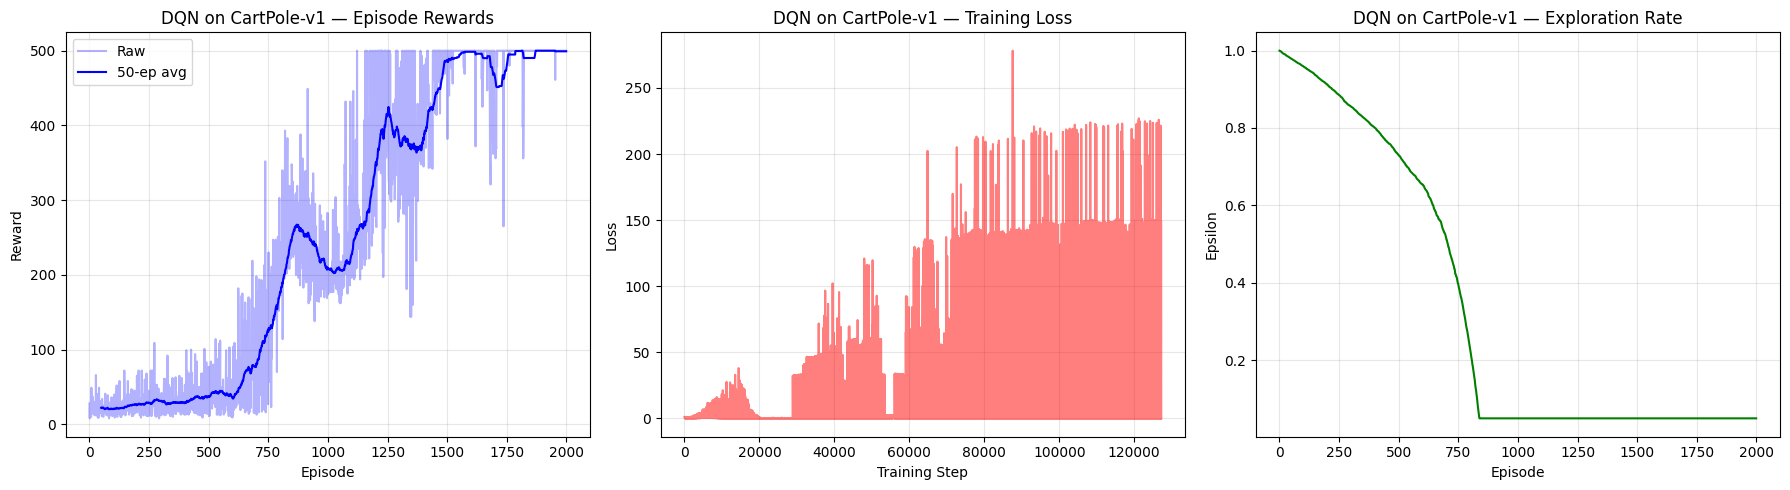


Average reward (last 100 episodes): 499.6
CartPole SOLVED! (>=475/500 average reward)


In [9]:
# Train DQN on CartPole
set_seed(42)
results_dqn = train_dqn(
    env_name="CartPole-v1",
    num_episodes=2000,
    solve_threshold=475,
    use_double_dqn=False,
    use_dueling=False,
    seed=42,
)

plot_training_results(results_dqn, title="DQN on CartPole-v1")

# Check if solved
last_100 = results_dqn['episode_rewards'][-100:]
avg_reward = np.mean(last_100)
print(f"\nAverage reward (last 100 episodes): {avg_reward:.1f}")
if avg_reward >= 475:
    print("CartPole SOLVED! (>=475/500 average reward)")
else:
    print("Not yet solved — check your implementation.")

## A.9 — Visualize the Learned Policy

Let's watch the trained agent play! We record a video of the agent's greedy policy (no exploration) and also visualize Q-value statistics.

In [10]:
def record_agent_video(agent, env_name="CartPole-v1", video_dir=None, num_episodes=3, seed=0):
    """
    Record video(s) of the trained agent playing with greedy policy.
    Videos are saved to experiments/videos/ and can be displayed inline.
    """
    if video_dir is None:
        video_dir = os.path.join(EXPERIMENTS_DIR, 'videos')
    os.makedirs(video_dir, exist_ok=True)

    env = gym.make(env_name, render_mode="rgb_array")
    env = gym.wrappers.RecordVideo(
        env,
        video_folder=video_dir,
        episode_trigger=lambda ep: True,
        name_prefix=f"dqn_{env_name}"
    )

    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        episode_reward = 0

        for step in range(10000):
            with torch.no_grad():
                state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
                action = agent.q_network(state_tensor).argmax(dim=1).item()

            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            if terminated or truncated:
                break

        print(f"Episode {ep+1}: reward = {episode_reward:.0f}, length = {step+1}")

    env.close()

    video_files = sorted([f for f in os.listdir(video_dir) if f.endswith('.mp4')])
    if video_files:
        video_path = os.path.join(video_dir, video_files[-1])
        print(f"\nVideo saved to: {video_path}")
        return video_path
    return None


def evaluate_and_plot(agent, env_name="CartPole-v1", num_episodes=20, seed=0):
    """Evaluate the trained agent and plot Q-value analysis."""
    env = gym.make(env_name)
    rewards, all_q_values = [], []

    for ep in range(num_episodes):
        obs, info = env.reset(seed=seed + ep)
        episode_reward = 0
        for step in range(10000):
            with torch.no_grad():
                state_tensor = torch.FloatTensor(obs).unsqueeze(0).to(device)
                q_values = agent.q_network(state_tensor)
                all_q_values.append(q_values.cpu().numpy().flatten())
                action = q_values.argmax(dim=1).item()
            obs, reward, terminated, truncated, info = env.step(action)
            episode_reward += reward
            if terminated or truncated:
                break
        rewards.append(episode_reward)

    env.close()
    q_values = np.array(all_q_values)

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    axes[0].bar(range(len(rewards)), rewards, color='steelblue', alpha=0.8)
    axes[0].axhline(y=np.mean(rewards), color='red', linestyle='--', label=f'Mean: {np.mean(rewards):.1f}')
    axes[0].set_xlabel('Episode'); axes[0].set_ylabel('Reward')
    axes[0].set_title(f'Evaluation (Greedy Policy) — {num_episodes} episodes')
    axes[0].legend(); axes[0].grid(True, alpha=0.3)

    for a in range(q_values.shape[1]):
        axes[1].hist(q_values[:, a], bins=50, alpha=0.6, label=f'Action {a}')
    axes[1].set_xlabel('Q-value'); axes[1].set_ylabel('Count')
    axes[1].set_title('Q-value Distribution by Action')
    axes[1].legend(); axes[1].grid(True, alpha=0.3)

    q_diff = q_values[:, 1] - q_values[:, 0]
    axes[2].hist(q_diff, bins=50, color='purple', alpha=0.7)
    axes[2].axvline(x=0, color='red', linestyle='--', label='No preference')
    axes[2].set_xlabel('Q(right) - Q(left)'); axes[2].set_ylabel('Count')
    axes[2].set_title('Action Preference')
    axes[2].legend(); axes[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()
    print(f"Evaluation: {np.mean(rewards):.1f} ± {np.std(rewards):.1f} "
          f"(min={min(rewards):.0f}, max={max(rewards):.0f})")

print("Visualization functions defined!")

Visualization functions defined!


In [11]:
# Record a video of the trained agent playing
video_path = record_agent_video(results_dqn['agent'], env_name="CartPole-v1", num_episodes=3)

# Display the video inline in the notebook
if video_path:
    display(Video(video_path, embed=True, width=480))

Episode 1: reward = 500, length = 500
Episode 2: reward = 500, length = 500
Episode 3: reward = 500, length = 500

Video saved to: c:\Users\arvid\Code\tdde78\labs\lab1_value_based\experiments\videos\dqn_CartPole-v1-episode-2.mp4


---

# Part B — Experiments

---

Now that your implementation works, run systematic experiments to understand the algorithms.

**Important:** For all experiments, run at least **3 different seeds** and report mean ± std.

## B.1 — DQN vs Double DQN vs Dueling DQN on CartPole

Compare the three variants on CartPole-v1. Run each with seeds [42, 123, 456].

Episode 50/2000 | Avg Reward (50): 22.0 | Avg Loss: 0.8975 | Epsilon: 0.979
Episode 100/2000 | Avg Reward (50): 20.4 | Avg Loss: 0.1955 | Epsilon: 0.960
Episode 150/2000 | Avg Reward (50): 23.6 | Avg Loss: 0.1082 | Epsilon: 0.937
Episode 200/2000 | Avg Reward (50): 26.3 | Avg Loss: 0.1764 | Epsilon: 0.912
Episode 250/2000 | Avg Reward (50): 28.4 | Avg Loss: 0.2740 | Epsilon: 0.885
Episode 300/2000 | Avg Reward (50): 31.0 | Avg Loss: 0.3696 | Epsilon: 0.856
Episode 350/2000 | Avg Reward (50): 29.0 | Avg Loss: 0.4181 | Epsilon: 0.828
Episode 400/2000 | Avg Reward (50): 28.6 | Avg Loss: 0.4674 | Epsilon: 0.801
Episode 450/2000 | Avg Reward (50): 36.8 | Avg Loss: 0.6117 | Epsilon: 0.766
Episode 500/2000 | Avg Reward (50): 37.3 | Avg Loss: 0.7200 | Epsilon: 0.731
Episode 550/2000 | Avg Reward (50): 44.7 | Avg Loss: 0.8782 | Epsilon: 0.688
Episode 600/2000 | Avg Reward (50): 35.9 | Avg Loss: 1.1764 | Epsilon: 0.654
Episode 650/2000 | Avg Reward (50): 67.1 | Avg Loss: 1.7140 | Epsilon: 0.590


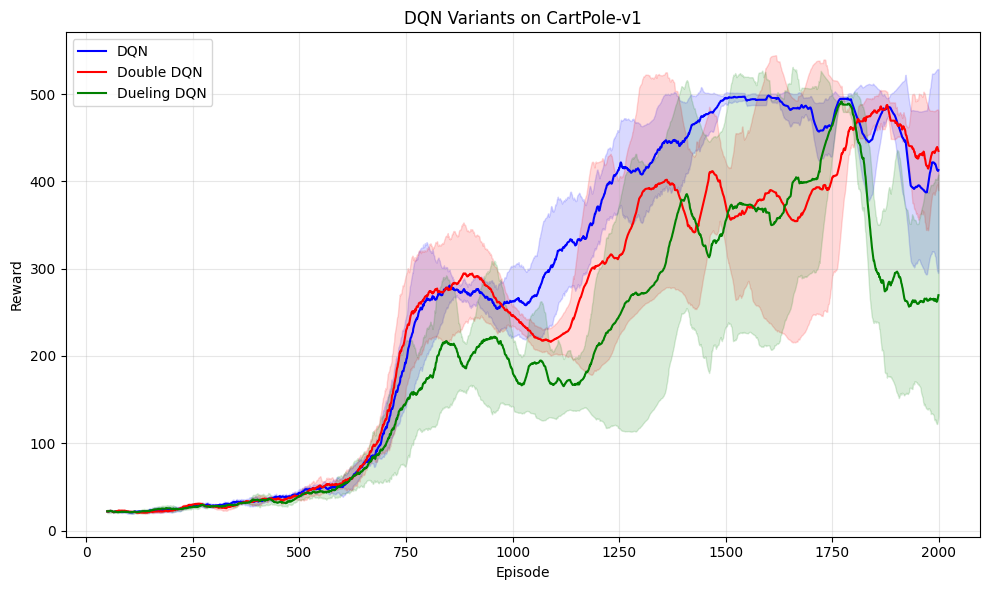

DQN: 403.4 ± 98.3
Double DQN: 431.2 ± 53.6
Dueling DQN: 264.8 ± 114.7


In [13]:
# =====================================================================
# TODO: Run DQN, Double DQN, and Dueling DQN on CartPole-v1
#       with seeds [42, 123, 456]. Store results and plot comparison.
#
# Run all variants for the full num_episodes (no solve_threshold) so you
# can compare post-solve stability — does DQN collapse after solving?
#
# Example structure:
#   seeds = [42, 123, 456]
#   all_results = {
#       'DQN':        [train_dqn(env_name="CartPole-v1", num_episodes=2000, seed=s) for s in seeds],
#       'Double DQN': [train_dqn(env_name="CartPole-v1", num_episodes=2000, use_double_dqn=True, seed=s) for s in seeds],
#       'Dueling DQN':[train_dqn(env_name="CartPole-v1", num_episodes=2000, use_dueling=True, seed=s) for s in seeds],
#   }
#   plot_comparison(all_results, title="DQN Variants on CartPole-v1")
#
#   for name, results_list in all_results.items():
#       final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
#       print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")
# =====================================================================
seeds = [42, 123, 456]
all_results = {
    'DQN': [train_dqn(env_name="CartPole-v1", num_episodes=2000, seed=s) for s in seeds],
    'Double DQN': [train_dqn(env_name="CartPole-v1", num_episodes=2000, use_double_dqn=True, seed=s) for s in seeds],
    'Dueling DQN': [train_dqn(env_name="CartPole-v1", num_episodes=2000, use_dueling=True, seed=s) for s in seeds],
}

#Plot comparison
plot_comparison(all_results, title="DQN Variants on CartPole-v1")

#Print final performance
for name, results_list in all_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

## B.2 — DQN on LunarLander-v3

Scale up to a harder environment. LunarLander has a larger state space and requires more careful learning.

Episode 50/1000 | Avg Reward (50): -157.1 | Avg Loss: 67.0611 | Epsilon: 0.762
Episode 100/1000 | Avg Reward (50): -93.0 | Avg Loss: 45.6888 | Epsilon: 0.285
Episode 150/1000 | Avg Reward (50): 54.8 | Avg Loss: 24.6836 | Epsilon: 0.050
Episode 200/1000 | Avg Reward (50): 97.0 | Avg Loss: 10.0972 | Epsilon: 0.050
Episode 250/1000 | Avg Reward (50): 91.5 | Avg Loss: 4.4982 | Epsilon: 0.050
Episode 300/1000 | Avg Reward (50): 222.6 | Avg Loss: 11.0611 | Epsilon: 0.050
Episode 350/1000 | Avg Reward (50): 231.3 | Avg Loss: 13.1317 | Epsilon: 0.050
Episode 400/1000 | Avg Reward (50): 224.8 | Avg Loss: 15.4876 | Epsilon: 0.050
Episode 450/1000 | Avg Reward (50): 119.8 | Avg Loss: 19.2110 | Epsilon: 0.050
Episode 500/1000 | Avg Reward (50): 107.1 | Avg Loss: 29.6593 | Epsilon: 0.050
Episode 550/1000 | Avg Reward (50): 170.9 | Avg Loss: 27.2082 | Epsilon: 0.050
Episode 600/1000 | Avg Reward (50): 238.2 | Avg Loss: 28.0563 | Epsilon: 0.050
Episode 650/1000 | Avg Reward (50): 248.9 | Avg Loss: 18

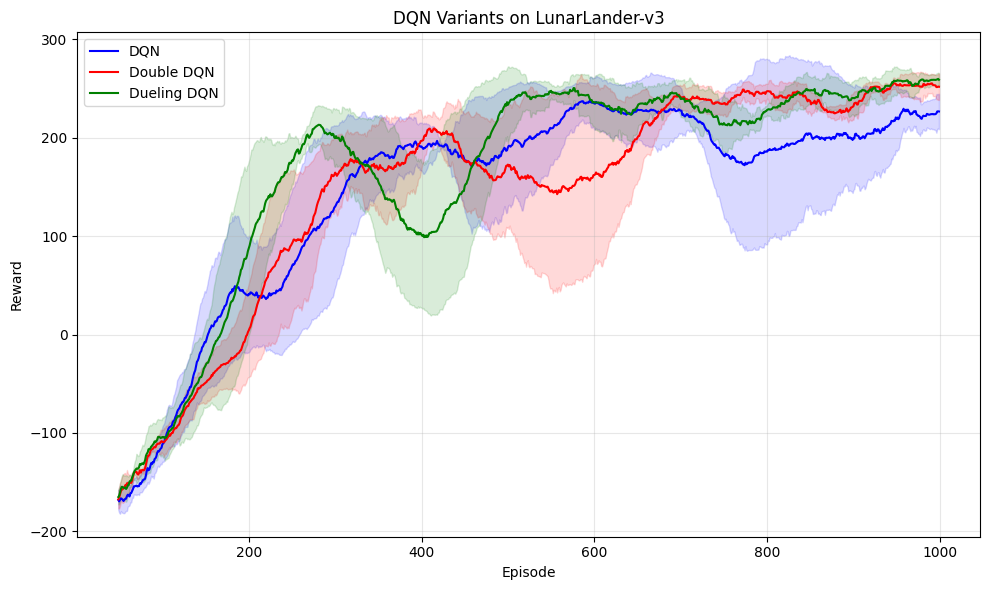

DQN: 223.7 ± 25.5
Double DQN: 253.3 ± 9.1
Dueling DQN: 258.3 ± 10.5


In [15]:
# =====================================================================
# TODO: Train DQN (and optionally Double/Dueling) on LunarLander-v3.
#       You may need more episodes (e.g., 1000) and different hyperparameters.
#       Run with at least 3 seeds and plot results.
#
#       Target: Average reward >= 200 over last 100 episodes.
# =====================================================================
seeds = [42, 123, 456]

all_results = {
    'DQN': [train_dqn(env_name="LunarLander-v3", num_episodes=1000, seed=s, learning_starts=1000, train_frequency=4,
            buffer_size=50000, batch_size=128, target_network_frequency=500, epsilon_decay=20000) for s in seeds],

    'Double DQN': [train_dqn(env_name="LunarLander-v3", num_episodes=1000, seed=s, use_double_dqn=True, learning_starts=1000, train_frequency=4,
            buffer_size=50000, batch_size=128, target_network_frequency=500, epsilon_decay=20000) for s in seeds],
            
    'Dueling DQN': [train_dqn(env_name="LunarLander-v3", num_episodes=1000, seed=s, use_dueling=True, learning_starts=1000, train_frequency=4,
            buffer_size=50000, batch_size=128, target_network_frequency=500, epsilon_decay=20000) for s in seeds],
}

plot_comparison(all_results, title="DQN Variants on LunarLander-v3")

for name, results_list in all_results.items():
    final_rewards = [np.mean(r['episode_rewards'][-100:]) for r in results_list]
    print(f"{name}: {np.mean(final_rewards):.1f} ± {np.std(final_rewards):.1f}")

## B.3 — Ablation: Replay Buffer Size

Investigate how the replay buffer size affects learning stability and performance.

Test buffer sizes: **1,000**, **10,000**, **100,000**

In [ ]:
# =====================================================================
# TODO: Run DQN on CartPole with different buffer sizes.
#       Use seeds [42, 123, 456] for each setting.
#       Plot comparison and analyze the effect.
#
#   buffer_sizes = [1000, 10000, 100000]
# =====================================================================
raise NotImplementedError("Run replay buffer ablation")

## B.4 — Ablation: Target Network Update Frequency

Investigate the effect of how often the target network is synchronized.

Test update frequencies: **1** (every step), **10**, **100**, **1000** steps

In [ ]:
# =====================================================================
# TODO: Run DQN on CartPole with different target update frequencies.
#       Use seeds [42, 123, 456] for each setting.
#       Plot comparison and analyze the effect.
#
#   target_update_freqs = [1, 10, 100, 1000]
# =====================================================================
raise NotImplementedError("Run target update frequency ablation")

## B.5 — Ablation: Epsilon Decay Schedule

Compare different exploration strategies.

Test epsilon decay lengths: **1,000**, **5,000**, **10,000**, **50,000** steps

In [ ]:
# =====================================================================
# TODO: Run DQN on CartPole with different epsilon decay schedules.
#       Use seeds [42, 123, 456] for each setting.
#       Plot comparison and analyze the effect.
#
#   epsilon_decays = [1000, 5000, 10000, 50000]
# =====================================================================
raise NotImplementedError("Run epsilon decay ablation")

---

## Summary

**TODO:** Write a brief summary of your findings from this lab (double-click to edit).

1. What are the two key components that make DQN stable (vs naive Q-learning with neural networks)?
2. When does Double DQN help the most? When does it not matter?
3. What is the benefit of the Dueling architecture, and on which environment did it help most?
4. Which hyperparameter (buffer size, target update frequency, epsilon decay) had the largest impact on performance, and why?
5. What would you investigate next if you had more time?

---

**Lab designed by Amath Sow:** amath.sow@liu.se

**TDDE78 — Deep Reinforcement Learning, Linköping University, Spring 2026**